# Quaternion Orientation Data Analysis

Analysis of the orientation prediction training data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
df_raw = pd.read_csv("../data/raw_data.csv")
df_processed = pd.read_csv("../data/orientation_training_data.csv")

# Column definitions
ORIENTATION_COLS = [
    "current_orientation_w",
    "current_orientation_x",
    "current_orientation_y",
    "current_orientation_z",
]
TARGET_COLS = [
    "orientation_change_w",
    "orientation_change_x",
    "orientation_change_y",
    "orientation_change_z",
]
CONTROL_COLS = ["pad_input_x", "pad_input_y"]
ANGULAR_VEL_COLS = ["angular_velocity_x", "angular_velocity_y", "angular_velocity_z"]

raw = df_raw[ORIENTATION_COLS].values
processed = df_processed[ORIENTATION_COLS].values

print(f"Loaded {len(df_raw):,} samples")
print(f"Columns: {list(df_raw.columns)}")

Loaded 100,000 samples
Columns: ['current_orientation_w', 'current_orientation_x', 'current_orientation_y', 'current_orientation_z', 'pad_input_x', 'pad_input_y', 'angular_velocity_x', 'angular_velocity_y', 'angular_velocity_z', 'timestep_seconds', 'orientation_change_w', 'orientation_change_x', 'orientation_change_y', 'orientation_change_z']


## 1. Raw vs Processed Orientation Quaternions

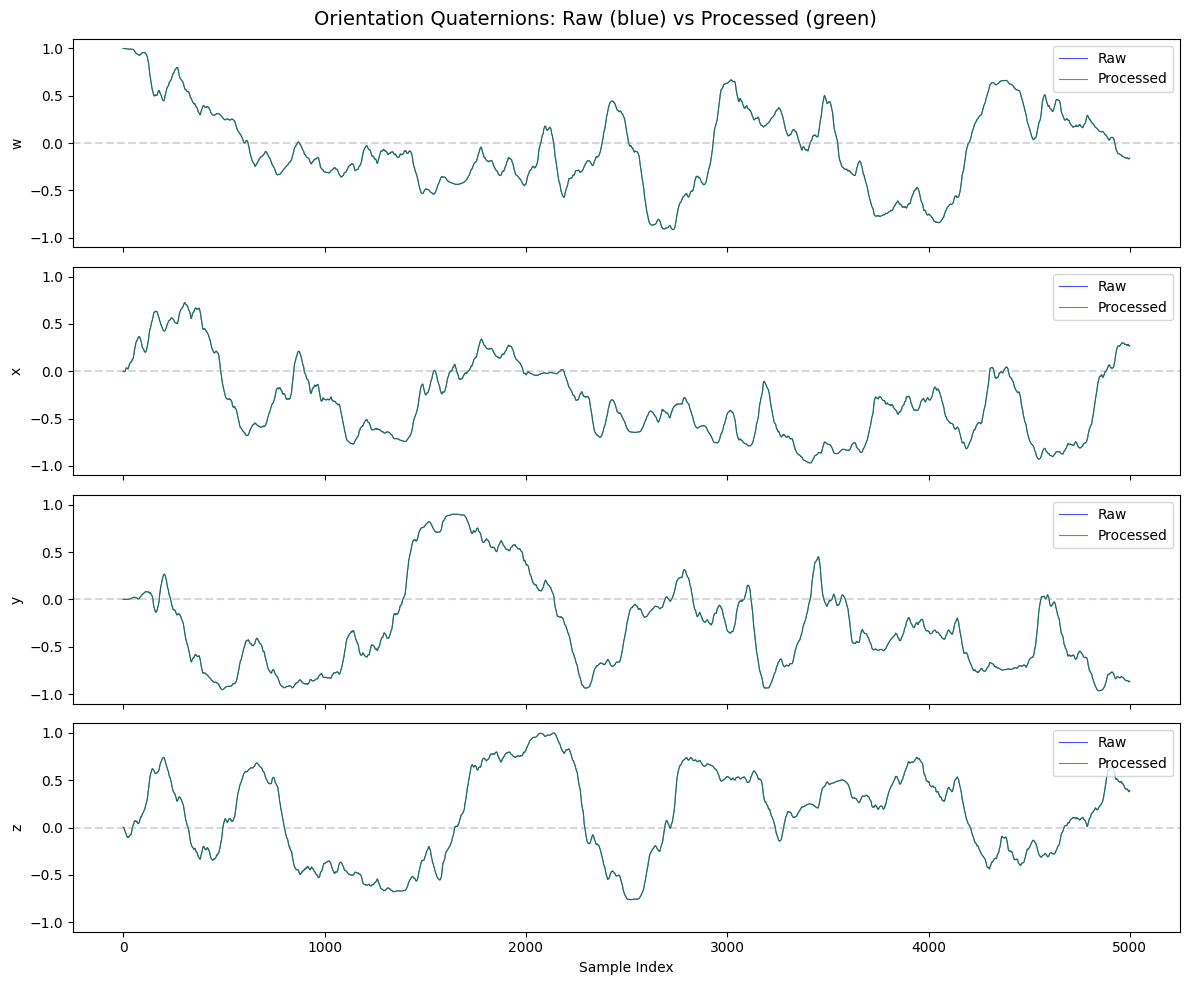

In [11]:
# Plot raw vs processed orientation quaternions
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

n_samples = 5_000
components = ["w", "x", "y", "z"]

for i, comp in enumerate(components):
    axes[i].plot(raw[:n_samples, i], "b-", alpha=0.7, linewidth=0.8, label="Raw")
    axes[i].plot(
        processed[:n_samples, i], "g-", alpha=0.7, linewidth=0.8, label="Processed"
    )
    axes[i].set_ylabel(comp)
    axes[i].set_ylim(-1.1, 1.1)
    axes[i].axhline(y=0, color="gray", linestyle="--", alpha=0.3)
    axes[i].legend(loc="upper right")

axes[3].set_xlabel("Sample Index")
fig.suptitle("Orientation Quaternions: Raw (blue) vs Processed (green)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Basic Statistics

In [5]:
# Summary statistics
print("Data Summary")
print("=" * 60)
df_processed.describe()

Data Summary


,current_orientation_w,current_orientation_x,current_orientation_y,current_orientation_z,pad_input_x,pad_input_y,angular_velocity_x,angular_velocity_y,angular_velocity_z,timestep_seconds,orientation_change_w,orientation_change_x,orientation_change_y,orientation_change_z
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000
mean,-0.006637,-0.009801,0.022892,0.046517,0.000271,0.000937,-0.005843,0.0,-0.001588,0.030034,0.999912,-0.000078,-2.334595e-19,-0.000035
std,0.493560,0.512953,0.510363,0.479572,0.577664,0.577146,0.570034,0.0,0.569301,0.011538,0.000126,0.009366,3.531930e-17,0.009394
min,-0.998660,-0.998418,-0.995193,-0.993824,-0.999977,-0.999995,-2.438042,0.0,-2.340204,0.010000,0.997929,-0.049135,-1.665335e-16,-0.056085
25%,-0.396015,-0.420761,-0.356913,-0.318861,-0.501154,-0.501503,-0.388098,0.0,-0.390223,0.020074,0.999890,-0.005098,-1.387779e-17,-0.005156
50%,-0.018315,-0.015262,0.028419,0.069424,0.002313,0.002099,0.001176,0.0,-0.009175,0.030051,0.999959,0.000013,0.000000e+00,-0.000111
75%,0.371877,0.395945,0.440877,0.426684,0.499861,0.499962,0.379461,0.0,0.379336,0.040017,0.999987,0.005009,1.387779e-17,0.004971
max,1.000000,0.998784,0.995922,0.999226,0.999966,0.999979,2.212825,0.0,2.574420,0.050000,1.000000,0.048057,1.674008e-16,0.054323


## 3. Correlation Matrix

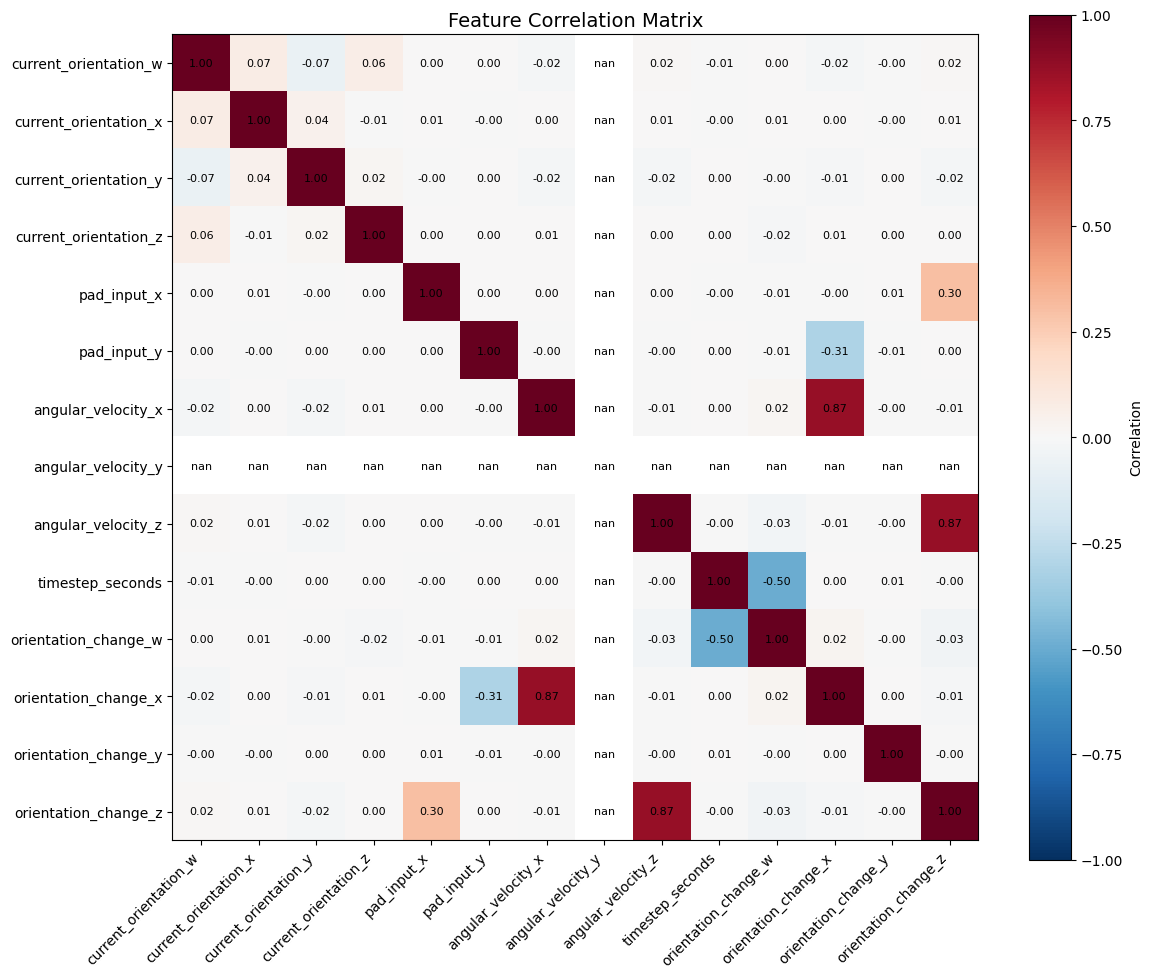

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = df_processed.corr()
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

# Labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax.text(
            j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8
        )

plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Orientation Distribution in 3D Space

Visualize where orientations point by applying each quaternion to a reference forward vector [0, 0, 1].

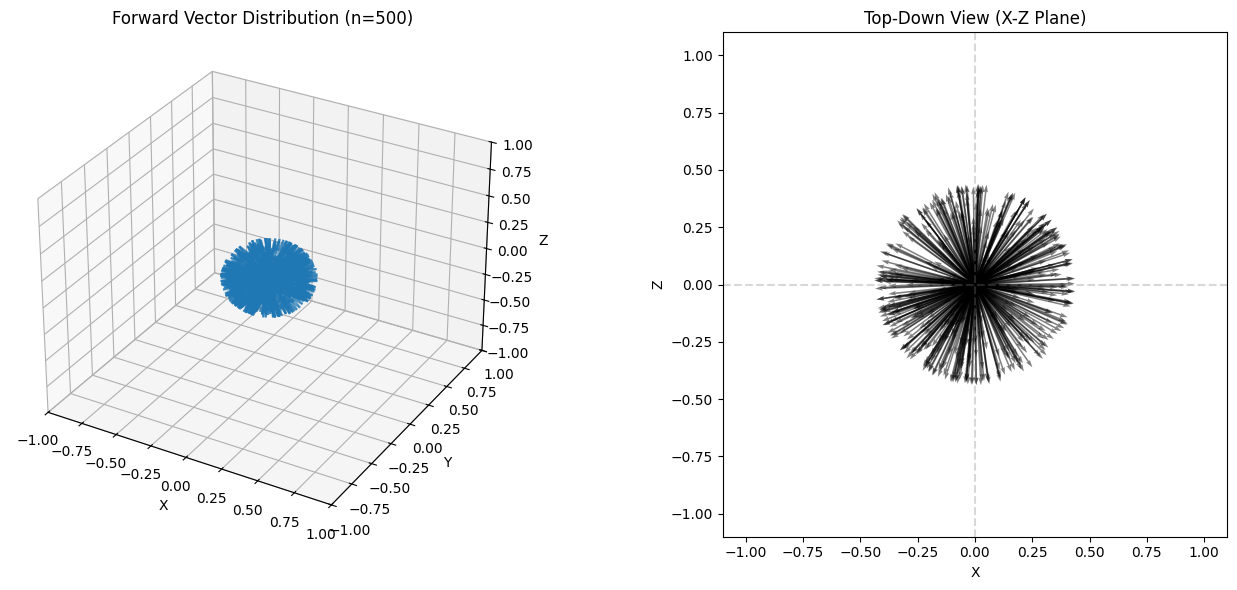

Forward vector ranges:
  X: [-1.000, 1.000]
  Y: [-1.000, 1.000]
  Z: [-1.000, 1.000]


In [7]:
def quaternion_rotate_vector(q, v):
    """Rotate vector v by quaternion q (q = [w, x, y, z])."""
    w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    vx, vy, vz = v

    # Quaternion rotation: v' = q * v * q^-1
    # Expanded formula for efficiency
    t0 = 2.0 * (x * vx + y * vy + z * vz)
    t1 = w * w - x * x - y * y - z * z
    t2 = 2.0 * w

    rx = t0 * x + t1 * vx + t2 * (y * vz - z * vy)
    ry = t0 * y + t1 * vy + t2 * (z * vx - x * vz)
    rz = t0 * z + t1 * vz + t2 * (x * vy - y * vx)

    return np.stack([rx, ry, rz], axis=1)


# Get orientations and rotate forward vector [0, 0, 1]
orientations = df_processed[ORIENTATION_COLS].values
forward_vectors = quaternion_rotate_vector(orientations, [0, 0, 1])

# Subsample for visualization (fewer for quiver since arrows are heavier to render)
n_viz = 500
indices = np.random.choice(len(forward_vectors), n_viz, replace=False)
fwd_sample = forward_vectors[indices]

# Create 3D plot with vectors
fig = plt.figure(figsize=(14, 6))

# View 1: 3D quiver (vectors from origin)
ax1 = fig.add_subplot(121, projection="3d")
origin = np.zeros((n_viz, 3))
ax1.quiver(
    origin[:, 0],
    origin[:, 1],
    origin[:, 2],
    fwd_sample[:, 0],
    fwd_sample[:, 1],
    fwd_sample[:, 2],
    length=0.3,
    normalize=True,
    alpha=0.5,
    arrow_length_ratio=0.3,
)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.set_title(f"Forward Vector Distribution (n={n_viz})")
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_zlim(-1, 1)

# View 2: Top-down (X-Z plane) with arrows
ax2 = fig.add_subplot(122)
ax2.quiver(
    np.zeros(n_viz),
    np.zeros(n_viz),
    fwd_sample[:, 0],
    fwd_sample[:, 2],
    alpha=0.5,
    scale=5,
    width=0.003,
)
ax2.set_xlabel("X")
ax2.set_ylabel("Z")
ax2.set_title("Top-Down View (X-Z Plane)")
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_aspect("equal")
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax2.axvline(x=0, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Forward vector ranges:")
print(f"  X: [{forward_vectors[:, 0].min():.3f}, {forward_vectors[:, 0].max():.3f}]")
print(f"  Y: [{forward_vectors[:, 1].min():.3f}, {forward_vectors[:, 1].max():.3f}]")
print(f"  Z: [{forward_vectors[:, 2].min():.3f}, {forward_vectors[:, 2].max():.3f}]")

## 5. Angular Velocity Distributions

Distribution of angular velocity components (x, y, z) in rad/s.

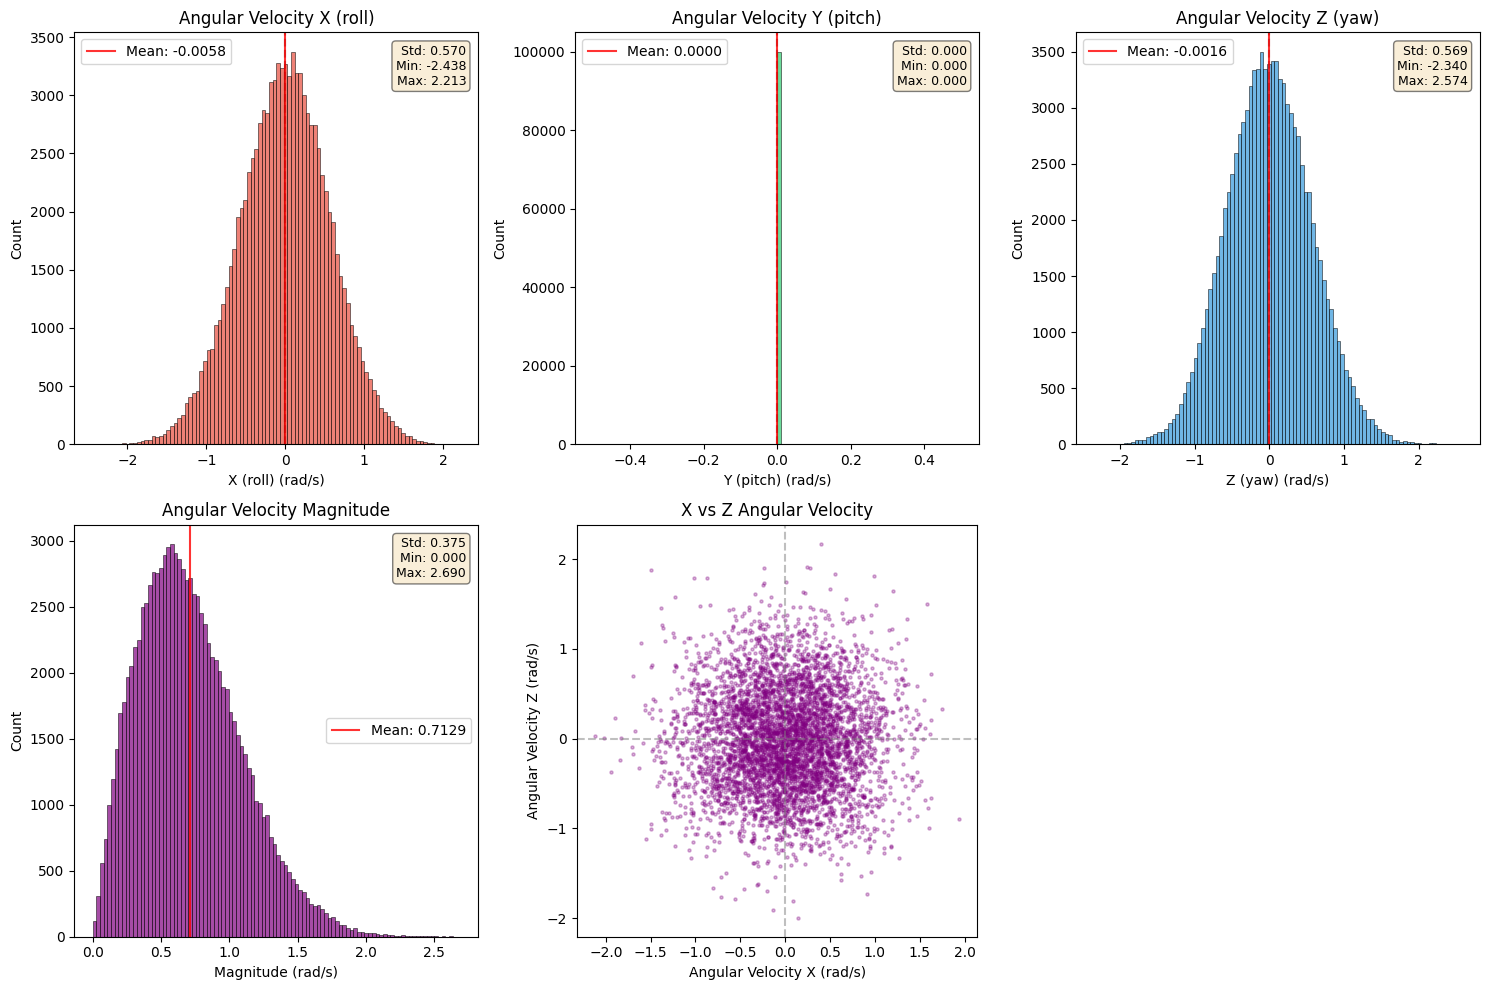

Angular Velocity Statistics:
------------------------------------------------------------
X (roll)    : mean= -0.0058, std=0.5700, range=[-2.438, 2.213]
Y (pitch)   : mean=  0.0000, std=0.0000, range=[0.000, 0.000]
Z (yaw)     : mean= -0.0016, std=0.5693, range=[-2.340, 2.574]
Magnitude   : mean=  0.7129, std=0.3752, range=[0.000, 2.690]


In [8]:
# Extract angular velocity data
ang_vel = df_processed[ANGULAR_VEL_COLS].values
ang_vel_magnitude = np.linalg.norm(ang_vel, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histogram for each component
colors = ["#e74c3c", "#2ecc71", "#3498db"]
labels = ["X (roll)", "Y (pitch)", "Z (yaw)"]

for i, (col, color, label) in enumerate(zip(ANGULAR_VEL_COLS, colors, labels)):
    ax = axes[0, i]
    data = df_processed[col].values

    ax.hist(data, bins=100, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axvline(x=0, color="black", linestyle="--", alpha=0.5)
    ax.axvline(
        x=data.mean(),
        color="red",
        linestyle="-",
        alpha=0.8,
        label=f"Mean: {data.mean():.4f}",
    )
    ax.set_xlabel(f"{label} (rad/s)")
    ax.set_ylabel("Count")
    ax.set_title(f"Angular Velocity {label}")
    ax.legend()

    # Add stats text
    stats_text = f"Std: {data.std():.3f}\nMin: {data.min():.3f}\nMax: {data.max():.3f}"
    ax.text(
        0.97,
        0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

# Magnitude histogram
ax_mag = axes[1, 0]
ax_mag.hist(
    ang_vel_magnitude,
    bins=100,
    color="purple",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)
ax_mag.axvline(
    x=ang_vel_magnitude.mean(),
    color="red",
    linestyle="-",
    alpha=0.8,
    label=f"Mean: {ang_vel_magnitude.mean():.4f}",
)
ax_mag.set_xlabel("Magnitude (rad/s)")
ax_mag.set_ylabel("Count")
ax_mag.set_title("Angular Velocity Magnitude")
ax_mag.legend()
stats_text = f"Std: {ang_vel_magnitude.std():.3f}\nMin: {ang_vel_magnitude.min():.3f}\nMax: {ang_vel_magnitude.max():.3f}"
ax_mag.text(
    0.97,
    0.97,
    stats_text,
    transform=ax_mag.transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

# 2D scatter of X vs Z (since Y is always 0)
ax_scatter = axes[1, 1]
n_scatter = min(5000, len(ang_vel))
indices = np.random.choice(len(ang_vel), n_scatter, replace=False)
ax_scatter.scatter(ang_vel[indices, 0], ang_vel[indices, 2], alpha=0.3, s=5, c="purple")
ax_scatter.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax_scatter.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax_scatter.set_xlabel("Angular Velocity X (rad/s)")
ax_scatter.set_ylabel("Angular Velocity Z (rad/s)")
ax_scatter.set_title("X vs Z Angular Velocity")
ax_scatter.set_aspect("equal")

# Hide unused subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Print summary
print("Angular Velocity Statistics:")
print("-" * 60)
for col, label in zip(ANGULAR_VEL_COLS, labels):
    data = df_processed[col]
    print(
        f"{label:12s}: mean={data.mean():8.4f}, std={data.std():.4f}, "
        f"range=[{data.min():.3f}, {data.max():.3f}]"
    )
print(
    f"{'Magnitude':12s}: mean={ang_vel_magnitude.mean():8.4f}, std={ang_vel_magnitude.std():.4f}, "
    f"range=[{ang_vel_magnitude.min():.3f}, {ang_vel_magnitude.max():.3f}]"
)